                                PPROJECT TITLE 
        Promotion Strategy Optimization in Retail Pharmacy 
                     Case Study: Nahdi Pharmacy Dubai Branch(Feb – Apr 2026)

Excetive  Summary:

This project evaluates the effectiveness of promotional strategies in a retail pharmacy setting.

 I focused on identifying categories that are heavily discounted without clear strategic justification, as well as seasonal patterns in discounting behavior.
 
Due to the absence of sales volume data, I reframed the analysis to assess promotional intensity and potential margin risk, using discount depth as a proxy. The goal was to highlight areas where the business may be over-discounting and recommend tighter promotion control to protect profitability.

The outcome is a decision-support framework for improving promotional governance and reducing unnecessary margin exposure.

Project Objectives:

detecting  inefficient promotion structures, and recommend strategies to optimize profitability while maintaining customer traffic.

Nahdi Pharmacy operates in a highly competitive, price-sensitive environment, where promotions are a key lever to:

Increase store traffic
Expand basket size
Defend market share against competitors

However, without robust optimization, promotions can create a false sense of growth—increasing revenue while silently eroding profitability.

1. Promotion Strategy Diagnostics

-Identifing dominant promotion types (e.g., % discount, bundle, BOGO)

-Evaluating distribution across categories and brands

-Identify categories with excessive promotional exposure


2. Discount Depth analysis


3.Evaluation of Promotion Effectiveness by Product Category


4.Gain Made by Customers vs Loss to Company


    -Customer savings (discount captured)

    -Company revenue sacrificed


Who benefits more — the customer or the business?




Data Constraints Acknowledgment 

Due to the absence of cost and customer-level data, the analysis focuses on proxy indicators of profitability, including:




If provided with full data here is what i will do:

I will redesign the strategy  into two main analysis that is customer centric and product centric.

Firstly i will redesign the  analysis around promotional effectiveness using three key metrics: incremental sales uplift, margin impact, and promotion ROI. First, I would establish a baseline of expected sales without promotion and compare it to actual sales during the promotion to calculate uplift. Then, I would evaluate whether the incremental revenue offsets the margin loss from discounting. Finally, I would classify promotions into high-performing and underperforming using a decision matrix, enabling the business to scale profitable promotions and eliminate those that erode margin without generating sufficient demand.

secondly i will redesign the  analysis around customer loyalty using the rfm model inorder to determine customer's loyalty,promotion centered customers and which customers are more likely to be eroded is discount are to be low or removed.

In [902]:
import pandas as pd
import numpy as np

import glob
import os

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor


import shap
shap.initjs()

In [903]:
def load_files(folder_path):

    df_list = []

    for file in os.listdir(folder_path):

        file_path = os.path.join(r"C:\Users\PAVILION PLUS\Desktop\nahdi data for analysis", file)

        try:

            if file.endswith(".csv"):
                df = pd.read_csv(file_path)

            elif file.endswith(".xlsx"):
                df = pd.read_excel(file_path)
            elif file.endswith('.js'):
                df=pd.read_json(file_path)
            elif file.endswith('.txt'):
                df=pd.read_table(file_path)

            else:
                continue

            df['source_file'] = file
            df_list.append(df)

            print(f"{file} loaded successfully")

        except Exception as e:
            print(f"Error loading {file}: {e}")

    return pd.concat(df_list, ignore_index=True)






# #faster version
# def load_excel_files(folder_path):

#     files = glob.glob(folder_path + "/*.xlsx")

#     df = pd.concat(
#         [pd.read_excel(file).assign(source_file=file.split("\\")[-1]) for file in files],
#         ignore_index=True
#     )

#     return df



# #production excel loader

# def load_promo_files(folder_path):

#     files = glob.glob(os.path.join(folder_path, "*.xlsx"))
#     df_list = []

#     for file in files:

#         try:

#             sheets = pd.read_excel(file, sheet_name=None)

#             for sheet_name, df in sheets.items():

#                 if df.empty:
#                     continue

#                 # Clean column names
#                 df.columns = (
#                     df.columns
#                     .str.strip()
#                     .str.lower()
#                     .str.replace(" ", "_")
#                 )

#                 # Track file + sheet
#                 df["source_file"] = os.path.basename(file)
#                 df["sheet_name"] = sheet_name

#                 df_list.append(df)

#             print(f"Loaded: {os.path.basename(file)}")

#         except Exception as e:

#             print(f"Error loading {file}: {e}")

#     combined_df = pd.concat(df_list, ignore_index=True, sort=False)

#     print(f"\nTotal rows loaded: {len(combined_df)}")

#     return combined_df

In [904]:
df = load_files(r"C:\Users\PAVILION PLUS\Desktop\nahdi data for analysis")
df

APRIL.xlsx loaded successfully
FEBRUARY.xlsx loaded successfully
MARCH.xlsx loaded successfully


,Division,Department,Category,Item Brand,Period,Channel,Group_Code,ITEM,English Description,OFFER TYPE,Price with VAT,Promo Price with VAT,Saving,Depth%,START_DATE,END_DATE,source_file
0,BEAUTY,COSMETIC,FRAGRANCES,Christian Dior,Full,BM & Online,FChor20,103184367,Christian Dior miss dior EDP100 ml,Direct_Discount,712.17,569.75,142.0,0.199997,2026-04-01,2026-04-30,APRIL.xlsx
1,BEAUTY,COSMETIC,FRAGRANCES,Christian Dior,Full,BM & Online,FChor20,103183866,Christian Dior sauvage Perfume 200 ml,Direct_Discount,1054.57,843.70,210.0,0.200000,2026-04-01,2026-04-30,APRIL.xlsx
2,BEAUTY,COSMETIC,FRAGRANCES,Christian Dior,Full,BM & Online,FChor20,103183807,Christian Dior pure poison EDP100 ml,Direct_Discount,712.17,569.75,142.0,0.199997,2026-04-01,2026-04-30,APRIL.xlsx
3,BEAUTY,COSMETIC,FRAGRANCES,Christian Dior,Full,BM & Online,FChor20,103181908,Christian Dior dior homme intense EDP150 ml,Direct_Discount,725.86,580.70,145.0,0.200000,2026-04-01,2026-04-30,APRIL.xlsx
4,BEAUTY,COSMETIC,FRAGRANCES,Christian Dior,Full,BM & Online,FChor20,103183129,Christian Dior hypnotic poison EDP100 ml,Direct_Discount,712.17,569.75,142.0,0.199997,2026-04-01,2026-04-30,APRIL.xlsx
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20952,WELLNESS,NUTRACEUTICALS AND NUTRITION,GENERAL HEALTH,Beatswell,Full,BM only,1_227650,102234692,Beatswell Vitamin C + Zinc 20 Effervescent Tab...,BUY 1 GET 1 FREE,50.00,25.05,24.0,NaN,2026-03-01,2026-03-31,MARCH.xlsx
20953,WELLNESS,NUTRACEUTICALS AND NUTRITION,WOMEN HEALTH,Beatswell,Full,BM only,1_227650,102209657,Beatswell Iron + Vitamin C 20 Effervescent Tab...,BUY 1 GET 1 FREE,58.11,29.10,29.0,NaN,2026-03-01,2026-03-31,MARCH.xlsx
20954,WELLNESS,NUTRACEUTICALS AND NUTRITION,GENERAL HEALTH,Beatswell,Full,BM only,1_227650,102525668,Beatswell Multivitamin Energy 20 Effervescent ...,BUY 1 GET 1 FREE,60.00,30.00,30.0,NaN,2026-03-01,2026-03-31,MARCH.xlsx
20955,WELLNESS,NUTRACEUTICALS AND NUTRITION,WOMEN HEALTH,Beatswell,Full,BM only,1_227650,102499615,Beatswell Calcium + Mg + D3 15 Effervescent Ta...,BUY 1 GET 1 FREE,49.80,24.90,24.0,NaN,2026-03-01,2026-03-31,MARCH.xlsx


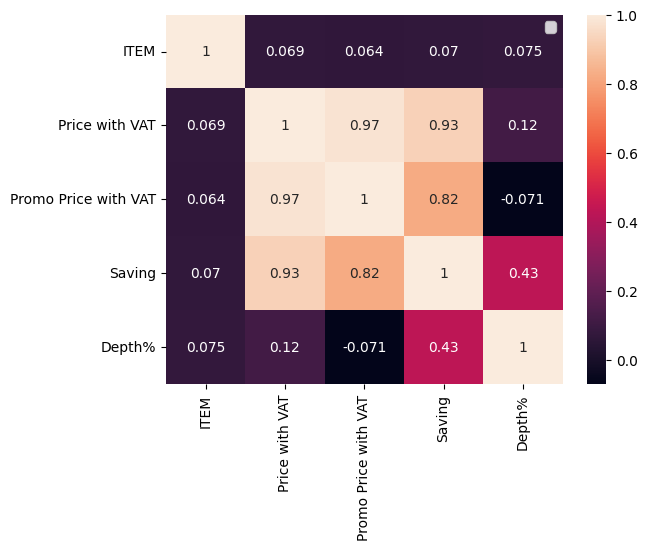

In [905]:
data_corr=df.corr(numeric_only=True)
sns.heatmap(data_corr,annot=True)
plt.legend('numerical correction')
plt.show()

In [906]:
df['START_DATE'] = pd.to_datetime(df['START_DATE'], errors='coerce')
df['END_DATE'] = pd.to_datetime(df['END_DATE'], errors='coerce')

FEATURE ENGINEERING

In [907]:
#Promotion Duration
df['Promo_Duration'] = (df['END_DATE'] - df['START_DATE']).dt.days

#Discount Percentage
df['Calculated_Discount'] = (df['Price with VAT'] - df['Promo Price with VAT']) / df['Price with VAT']*100

#Price Reduction
df['Price_Reduction'] = df['Price with VAT'] - df['Promo Price with VAT']

#Discount Depth
df['Discount_Depth'] = df['Saving'] / df['Price with VAT'] 

#Price Category
df['Price_Category'] = pd.qcut(df['Price with VAT'], q=4, labels=['Low','Medium','High','Premium'])

#calculated distance category
df['Calculated_Discount_catrgory']  = pd.qcut(df['Calculated_Discount'], q=3, labels=['Low','High','Premium'])

#Promotion Month
df['Promo_Month'] = df['START_DATE'].dt.month



#"corrected_Depth%"
mapping = {
    'BUY 2 GET 1 FREE ': 1,
    'BUY 1 GET 1 FREE ': 1,
    'BUY 2 GET 2 FREE ':2,
    'BUY 1 GET 1 WITH PERCENT OFF 30':.30, 
    'BUY 1 GET 1 WITH PERCENT OFF 40':.40,
    'BUY 1 GET 1 WITH PERCENT OFF 50':.50,
    'BUY 1 GET 1 WITH PERCENT OFF 60':.60,
    'BUY 1 GET 1 WITH PERCENT OFF 70':.70,
    'BUY 1 GET 2 FREE ':2,
    '(B/G) BUY 2 GET 1 FREE ':1,
    'BUY 1 GET 1 WITH PERCENT OFF 70': .30

}
df["corrected_Depth%"] = df.apply( lambda row: mapping[row["OFFER TYPE"]] if row["OFFER TYPE"] in mapping else row["Depth%"], axis=1)
# Promotion Risk Score
df['Promo_Risk_Score'] = df['corrected_Depth%'] * df['Promo_Duration']
#LABELS
mapping = {
    'Accez':'PL',
    'Active Go':'PL',
    'Alfoshan':'PL',
    'ALmisan':'PL', 
    'AURI':'PL',
    'Babygee':'PL',
    'Babywell':'PL',
    'Beatswell':'PL',
    'Bibi':'PL',
    'Bio-Synergy':'PL',
    'Blade':'PL',
    'Body Spa':'PL',
    'BODYLICIOUS':'PL',
    'Boutique':'PL',
    'Citizen':'PL',
    'Clary':'PL',
    'Clevie':'PL',
    'Clevie Derma':'PL',
    'Connect':'PL',
    'COXIR':'PL',
    'Creigtons':'PL',
    'Davids':'PL',
    'Emotion':'PL',
    'Eric Favre':'PL',
    'Febella':'PL',
    'First Aids Kit':'PL',
    'Footness':'PL',
    'Fragrances For Her':'PL',
    'Fruit Works':'PL',
    'Gamar':'PL',
    'Grit':'PL',
    'I Kuzma':'PL',
    'Kaiyang':'PL',
    'Keller':'PL',
    'Killys':'PL',
    'Mades':'PL',
    'Martini':'PL',
    'Medex':'PL',
    'Molfix':'PL',
    'Movera':'PL',
    'Movera Ortho':'PL',
    'Movera Sport':'PL',
    'MUVU':'PL',
    'Nahdi':'PL',
    'NUTSHELL':'PL',
    'OE':'PL',
    'OnCall':'PL',
    'Orex':'PL',
    'Parsa':'PL',
    'Parsa Beauty':'PL',
    'Qure':'PL',
    'Rosal':'PL',
    'Sanotact':'PL',
    'Shadez':'PL',
    'True Honey':'PL',
    'Velveta':'PL',
    'Viora':'PL',
    'Yunmai':'PL',
    'Yuwell':'PL',
    'ZAK':'PL'

}
df["LABELS"] = df.apply( lambda row: mapping[row["Item Brand"]] if row["Item Brand"] in mapping else 'OTHERS', axis=1)


DETAILING OF OBJECTIVES

# OBJECTIVE 1.Promotion Strategy Diagnostics

OFFER TYPE
Direct_Discount                    26.998139
BUY 2 GET 1 FREE                   23.495729
BUY 1 GET 1 FREE                   16.481367
BUY 1 GET 1 WITH PERCENT OFF 50    10.841246
BUY 2 GET 2 FREE                    9.634013
BUY 1 GET 1 WITH PERCENT OFF 40     8.751253
BUY 1 GET 1 WITH PERCENT OFF 30     2.648280
BUY 1 GET 1 WITH PERCENT OFF 60     0.763468
BUY 1 GET 2 FREE                    0.257670
(B/G) BUY 2 GET 1 FREE              0.081118
BUY 1 GET 1 WITH PERCENT OFF 70     0.047717
Name: proportion, dtype: float64


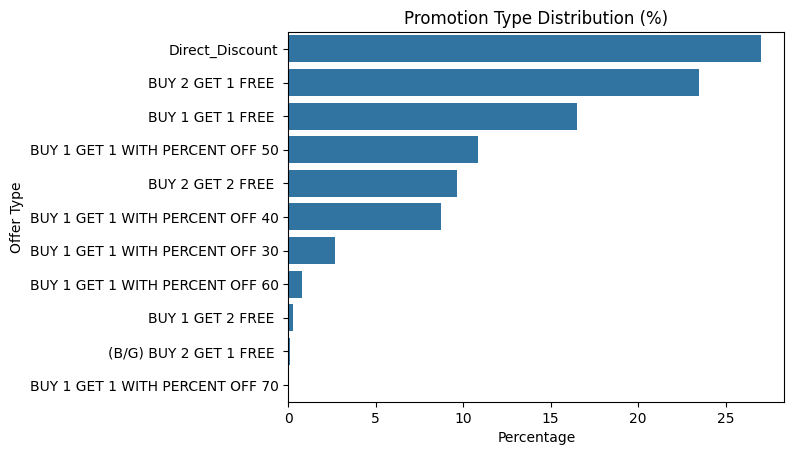

In [908]:
#1.1 Dominant Promotion Types
promo_dist = df['OFFER TYPE'].value_counts(normalize=True) * 100

print(promo_dist)

sns.barplot(x=promo_dist.values, y=promo_dist.index)
plt.title("Promotion Type Distribution (%)")
plt.xlabel("Percentage")
plt.ylabel("Offer Type")
plt.show()

In [909]:
#1.2
promo_dist_month = df.groupby('Promo_Month')['OFFER TYPE'].value_counts(normalize=True) * 100
promo_dist_month

Promo_Month  OFFER TYPE                     
2            BUY 2 GET 1 FREE                   27.146320
             BUY 2 GET 2 FREE                   24.837352
             Direct_Discount                    20.653145
             BUY 1 GET 1 FREE                   19.874984
             BUY 1 GET 1 WITH PERCENT OFF 50     5.931879
             BUY 1 GET 1 WITH PERCENT OFF 30     0.650593
             BUY 1 GET 1 WITH PERCENT OFF 60     0.331675
             BUY 1 GET 2 FREE                    0.306162
             (B/G) BUY 2 GET 1 FREE              0.140324
             BUY 1 GET 1 WITH PERCENT OFF 70     0.127567
3            Direct_Discount                    30.292490
             BUY 1 GET 1 WITH PERCENT OFF 40    25.849802
             BUY 1 GET 1 WITH PERCENT OFF 50    18.134387
             BUY 2 GET 1 FREE                   16.079051
             BUY 1 GET 1 FREE                    8.537549
             BUY 1 GET 2 FREE                    0.474308
             BUY 1 GET 1 WI

In [910]:
#1.3
promo_dist_month_labels = df.groupby(['LABELS','Promo_Month'])['OFFER TYPE'].value_counts(normalize=True) * 100
promo_dist_month_labels

LABELS  Promo_Month  OFFER TYPE                     
OTHERS  2            BUY 2 GET 1 FREE                   31.775422
                     BUY 2 GET 2 FREE                   29.072719
                     Direct_Discount                    18.605346
                     BUY 1 GET 1 FREE                   12.154696
                     BUY 1 GET 1 WITH PERCENT OFF 50     6.809019
                     BUY 1 GET 1 WITH PERCENT OFF 30     0.761535
                     BUY 1 GET 1 WITH PERCENT OFF 60     0.388234
                     BUY 1 GET 2 FREE                    0.358369
                     (B/G) BUY 2 GET 1 FREE              0.074660
        3            BUY 1 GET 1 WITH PERCENT OFF 40    31.273910
                     Direct_Discount                    29.648049
                     BUY 2 GET 1 FREE                   19.452946
                     BUY 1 GET 1 FREE                    9.429992
                     BUY 1 GET 1 WITH PERCENT OFF 50     8.856159
                     BU

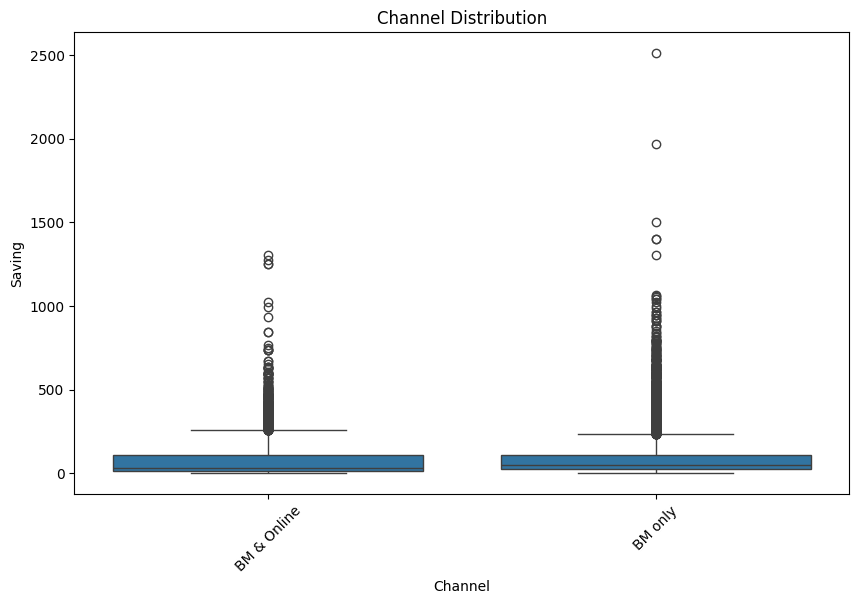

In [911]:
#1.4
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Channel', y='Saving')
plt.title("Channel Distribution")
plt.xticks(rotation=45)
plt.show()

In [912]:
#1.5 Distribution Across Categories & Brands

category_promo = pd.crosstab(df['Category'], df['OFFER TYPE'], normalize='index') * 100
brand_promo = pd.crosstab(df['Item Brand'], df['OFFER TYPE'], normalize='index') * 100



In [913]:
#1.6 Over-Reliance on Margin-Eroding Promotions

high_discount_threshold = df['corrected_Depth%'].quantile(0.75)

high_discount_ratio = (
    df[df['corrected_Depth%'] > high_discount_threshold]
    .groupby('Category')
    .size() / df.groupby('Category').size()
).fillna(0)

print(high_discount_ratio.sort_values(ascending=False))

Category
NAILS                      0.506438
MAKEUP                     0.321303
BEAUTY SKIN CARE           0.243051
HAIR TREATMENT             0.171990
DERMO SKIN CARE            0.127444
HAIR COLOR                 0.097087
HAIR REMOVALS              0.056818
PAIN MANAGEMENT            0.052632
MEN GROOMING               0.051282
HAND HYGIENE               0.034483
BABY TOILETRIES            0.025370
INTIMATE HYGIENE           0.020833
WOMEN HEALTH               0.015801
DEODORANTS                 0.013889
GENERAL HEALTH             0.009597
REGULAR SKIN CARE          0.004762
DAILY HAIR CARE            0.003546
BODY MOISTURIZERS          0.003300
BEAUTY ACCESSORIES         0.002411
CLEAN HAIR CARE            0.000000
BREATH FRESHENER           0.000000
BODY SUPPORT               0.000000
BODY FRESHENERS            0.000000
BABY WIPES                 0.000000
BATH AND SHOWER            0.000000
ADVANCED ORAL CARE         0.000000
BABY MILK                  0.000000
BABY FOOD          

In [914]:
#1.7  CATEGORY-LEVEL ANALYSIS

category_analysis = df.groupby('Category').agg({
    'corrected_Depth%': 'mean',
    'Promo_Risk_Score': 'mean',
    'ITEM': 'count'
}).rename(columns={'ITEM': 'Promo_Frequency'}).reset_index().sort_values(by='Promo_Risk_Score', ascending=False)

category_analysis 

,Category,corrected_Depth%,Promo_Risk_Score,Promo_Frequency
44,NAILS,1.471244,40.591511,466
37,MAKEUP,1.173885,32.192333,1995
39,MEN GROOMING,0.907692,26.046154,39
31,HOME HYGIENE,0.944444,25.888889,9
17,DERMO SKIN CARE,0.882603,25.027783,2762
29,HAND HYGIENE,0.881976,24.969794,319
18,DIABETIC CARE,0.887500,24.675000,20
35,KIDS HEALTH,0.855814,24.429460,129
41,MEN HEALTH,0.849038,24.418263,156
7,BEAUTY SKIN CARE,0.869190,24.315580,2806


In [915]:
# Sort by risk
category_analysis = category_analysis.sort_values(by='Promo_Risk_Score', ascending=False)

print("\n=== CATEGORY PROMOTION ANALYSIS ===")
print(category_analysis.head(10))


=== CATEGORY PROMOTION ANALYSIS ===
            Category  corrected_Depth%  Promo_Risk_Score  Promo_Frequency
44             NAILS          1.471244         40.591511              466
37            MAKEUP          1.173885         32.192333             1995
39      MEN GROOMING          0.907692         26.046154               39
31      HOME HYGIENE          0.944444         25.888889                9
17   DERMO SKIN CARE          0.882603         25.027783             2762
29      HAND HYGIENE          0.881976         24.969794              319
18     DIABETIC CARE          0.887500         24.675000               20
35       KIDS HEALTH          0.855814         24.429460              129
41        MEN HEALTH          0.849038         24.418263              156
7   BEAUTY SKIN CARE          0.869190         24.315580             2806


# OBJECTIVE 2.Discount Depth 

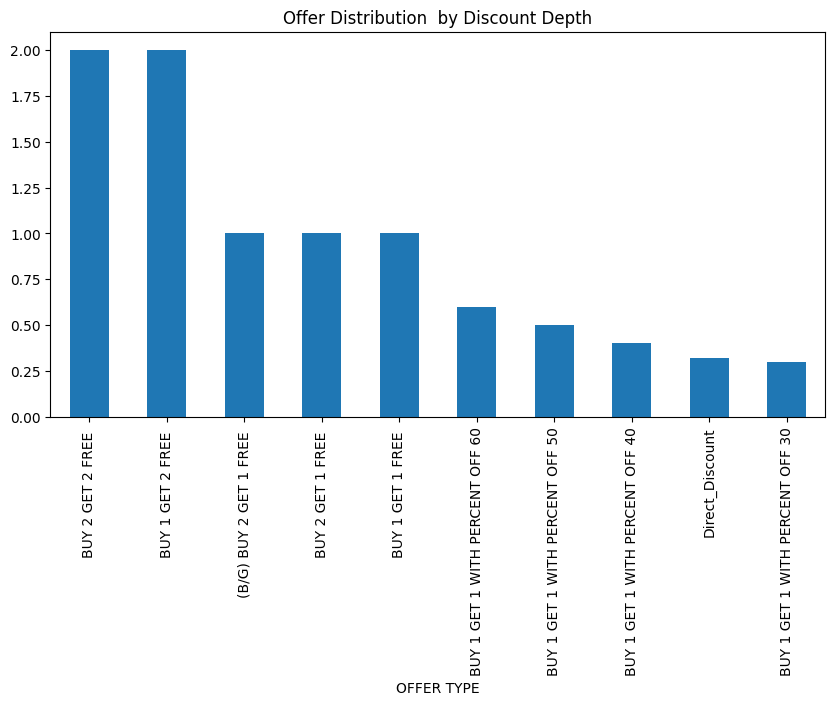

In [916]:
#1.2 discounting depth as per offer type
offer_distribution = (
    df.groupby('OFFER TYPE')['corrected_Depth%']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

offer_distribution.plot(kind='bar', figsize=(10,5), title='Offer Distribution  by Discount Depth')
plt.show()

In [917]:
#2.1 IDENTIFY OVER-PROMOTED CATEGORIES
# Thresholds 
high_discount_threshold = df['corrected_Depth%'].quantile(0.75)
high_frequency_threshold = category_analysis['Promo_Frequency'].quantile(0.75)

category_analysis['Risk_Level'] = np.where(
    (category_analysis['corrected_Depth%'] > high_discount_threshold) &
    (category_analysis['Promo_Frequency'] > high_frequency_threshold),
    'Critical',
    np.where(
        (category_analysis['corrected_Depth%'] > high_discount_threshold),
        'Moderate',
        'Low'
    )
)

print("\n=== RISK CLASSIFICATION ===")
print(category_analysis[['Category', 'Risk_Level']].head(10))





=== RISK CLASSIFICATION ===
            Category Risk_Level
44             NAILS   Critical
37            MAKEUP   Critical
39      MEN GROOMING        Low
31      HOME HYGIENE        Low
17   DERMO SKIN CARE        Low
29      HAND HYGIENE        Low
18     DIABETIC CARE        Low
35       KIDS HEALTH        Low
41        MEN HEALTH        Low
7   BEAUTY SKIN CARE        Low


In [918]:
# DECISION FRAMEWORK

def decision_rule(row):
    if row['Risk_Level'] == 'Critical':
        return 'Reduce or Stop Promotions'
    elif row['Risk_Level'] == 'Moderate':
        return 'Optimize Discount Strategy'
    else:
        return 'Maintain Strategy'

category_analysis['Recommended_Action'] = category_analysis.apply(decision_rule, axis=1)

print("\n=== FINAL RECOMMENDATIONS ===")
print(category_analysis[['Category', 'Risk_Level', 'Recommended_Action']].head(10))


=== FINAL RECOMMENDATIONS ===
            Category Risk_Level         Recommended_Action
44             NAILS   Critical  Reduce or Stop Promotions
37            MAKEUP   Critical  Reduce or Stop Promotions
39      MEN GROOMING        Low          Maintain Strategy
31      HOME HYGIENE        Low          Maintain Strategy
17   DERMO SKIN CARE        Low          Maintain Strategy
29      HAND HYGIENE        Low          Maintain Strategy
18     DIABETIC CARE        Low          Maintain Strategy
35       KIDS HEALTH        Low          Maintain Strategy
41        MEN HEALTH        Low          Maintain Strategy
7   BEAUTY SKIN CARE        Low          Maintain Strategy


# OBJECTIVE 3.Evaluation of Promotion Effectiveness by Product Category

In [919]:
df.groupby('LABELS').agg({'corrected_Depth%':'sum','Saving':'sum','Promo Price with VAT':'mean'})

,corrected_Depth%,Saving,Promo Price with VAT
LABELS,,,
OTHERS,14154.978487,1793127.0,183.627575
PL,2329.304547,111523.0,55.290190


In [920]:
df.groupby(['LABELS','OFFER TYPE'])['OFFER TYPE'].count()

LABELS  OFFER TYPE                     
OTHERS  (B/G) BUY 2 GET 1 FREE                5
        BUY 1 GET 1 FREE                   1912
        BUY 1 GET 1 WITH PERCENT OFF 30     555
        BUY 1 GET 1 WITH PERCENT OFF 40    1834
        BUY 1 GET 1 WITH PERCENT OFF 50    1579
        BUY 1 GET 1 WITH PERCENT OFF 60     160
        BUY 1 GET 2 FREE                     54
        BUY 2 GET 1 FREE                   4908
        BUY 2 GET 2 FREE                   2019
        Direct_Discount                    4551
PL      (B/G) BUY 2 GET 1 FREE               12
        BUY 1 GET 1 FREE                   1542
        BUY 1 GET 1 WITH PERCENT OFF 50     693
        BUY 1 GET 1 WITH PERCENT OFF 70      10
        BUY 2 GET 1 FREE                     16
        Direct_Discount                    1107
Name: OFFER TYPE, dtype: int64

# OBJECTIVE 4.Gain Made by Customers vs Loss to Company

In [921]:
#4.1 Customer Savings

total_customer_savings = df['Saving'].sum()

print('Customer Savings:')
print(total_customer_savings)

Customer Savings:
1904650.0


In [922]:
total_customer__monthly_savings = df.groupby('Promo_Month')['Saving'].sum()
total_customer__monthly_savings



Promo_Month
2    869627.0
3    475654.0
4    559369.0
Name: Saving, dtype: float64

In [923]:
#4.2 Company Revenue Sacrifice
total_revenue_sacrifice = (df['Price with VAT'] - df['Promo Price with VAT']).sum()
print('total_revenue_sacrifice:')
print(total_revenue_sacrifice) 

total_revenue_sacrifice:
1916947.5899999999


In [924]:
#4.3 Net Value Transfer
value_transfer = pd.DataFrame({
    'Metric': ['Customer Gain', 'Company Loss'],
    'Value': [total_customer_savings, total_revenue_sacrifice]
})

print(value_transfer)

          Metric       Value
0  Customer Gain  1904650.00
1   Company Loss  1916947.59


In [925]:
#4.4 Who Benefits More?

if total_customer_savings > total_revenue_sacrifice:
    print("Customers benefit more")
else:
    print("Company retains more value")

Company retains more value


MoM Analysis

In [926]:
# MONTHLY TREND ANALYSIS
df['Month'] = df['START_DATE'].dt.month
monthly_trend = df.groupby('Month').agg({
    'corrected_Depth%': 'mean',
    'Promo_Risk_Score': 'mean'
}).reset_index()

print("\n=== MONTHLY TREND ===")
print(monthly_trend)


=== MONTHLY TREND ===
   Month  corrected_Depth%  Promo_Risk_Score
0      2          1.076818         29.074098
1      3          0.556846         16.705393
2      4          0.665545         19.300816


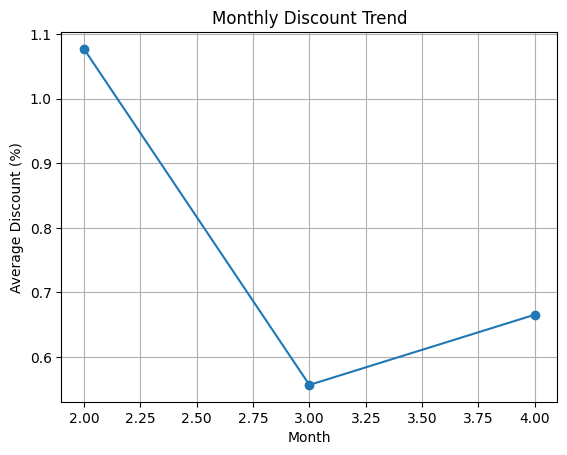

In [927]:
# 1. Monthly Discount Trend
plt.figure()
plt.plot(monthly_trend['Month'], monthly_trend['corrected_Depth%'], marker='o')
plt.title("Monthly Discount Trend")
plt.xlabel("Month")
plt.ylabel("Average Discount (%)")
plt.grid()
plt.show()

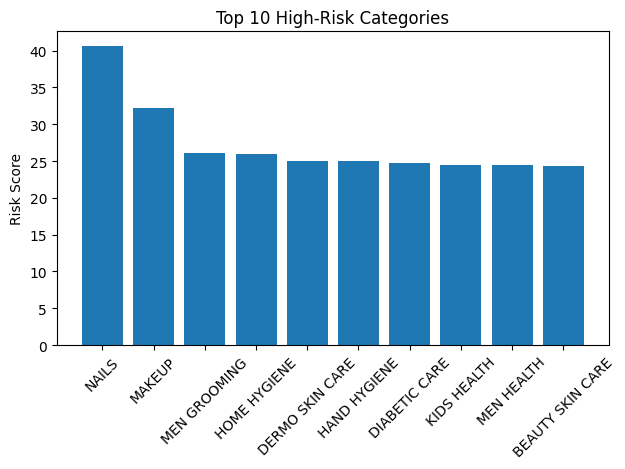

In [928]:
# 2. Top 10 Risky Categories
top_risk = category_analysis.head(10)

plt.figure()
plt.bar(top_risk['Category'], top_risk['Promo_Risk_Score'])
plt.title("Top 10 High-Risk Categories")
plt.xticks(rotation=45)
plt.ylabel("Risk Score")
plt.tight_layout()
plt.show()


RECOMMENDATIONS:


1. Shift from Volume-Driven to Profit-Driven Promotions
Introduce margin guardrails for all campaigns
Avoid deep discounting without clear ROI justification
2. Optimize Discount Depth
Identify and enforce optimal discount bands per category
Reduce unnecessary over-discounting
3. Prioritize High-Margin Categories
Focus promotions on products that:
Can absorb discounts
Drive profitable basket expansion
4. Implement Promotion Performance Dashboard
Track in real-time:
Revenue vs margin impact
Discount efficiency
Category performance
5. Move Toward Data-Driven Personalization (Future Scope)
Transition from blanket promotions to:
Targeted offers

Customer segmentation strategies (e.g., RFM)

Business Impact

This analysis enables leadership to:

Eliminate hidden financial leakage

Improve promotion ROI

Balance growth and profitability

Build a sustainable promotional strategy